# Freight Rate Prediction Using Machine Learning

## Objective

The goal of this project is to predict the posted freight rate of a shipment
using shipment characteristics such as distance, weight, equipment type,
market conditions, date information, and geographic regions.

The project compares several regression models and selects the best-performing
model based on MAE, RMSE, R², and MAPE.

## Dataset Columns

| Column | Type | Description |
|---|---|---|
| `load_id` | Categorical / ID | Unique identifier for each freight shipment or load. |
| `pickup` | Categorical | Name of the pickup city. |
| `delivery` | Categorical | Name of the delivery city. |
| `pickup_lat` | Numerical | Latitude of the pickup location. |
| `pickup_lon` | Numerical | Longitude of the pickup location. |
| `delivery_lat` | Numerical | Latitude of the delivery location. |
| `delivery_lon` | Numerical | Longitude of the delivery location. |
| `distance` | Numerical | Shipment distance between the pickup and delivery locations. |
| `equipment` | Categorical | Type of equipment used for the shipment, such as Dry Van, Reefer, or Flatbed. |
| `weight` | Numerical | Weight of the freight shipment. |
| `date` | Date / Time | Date associated with the freight load. |
| `market_index` | Numerical | Market-related index representing freight market conditions. |
| `quote_signal` | Numerical | Numerical signal associated with the freight quote. |
| `posted_rate` | Numerical / Target | Posted freight price that the machine-learning model aims to predict. |

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

Load the Datest

In [2]:
freight = pd.read_csv("train-test.csv")

freight.head()

print("Dataset shape:", freight.shape)

Dataset shape: (48000, 14)


Initial Data Exploration

In [3]:
freight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [4]:
freight.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [5]:
freight["equipment"].value_counts()


equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

In [6]:
freight["pickup"].value_counts()

pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
                 ... 
Detroit           337
Washington        337
St. Louis         318
Las Vegas         277
Dallas            276
Name: count, Length: 64, dtype: int64

In [7]:
freight["delivery"].value_counts()


delivery
Lexington      1197
Fort Wayne     1176
Baton Rouge    1167
Bakersfield    1156
Hartford       1143
               ... 
St. Louis       344
Birmingham      318
Detroit         307
Dallas          306
Las Vegas       292
Name: count, Length: 64, dtype: int64

In [8]:
freight.isna().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

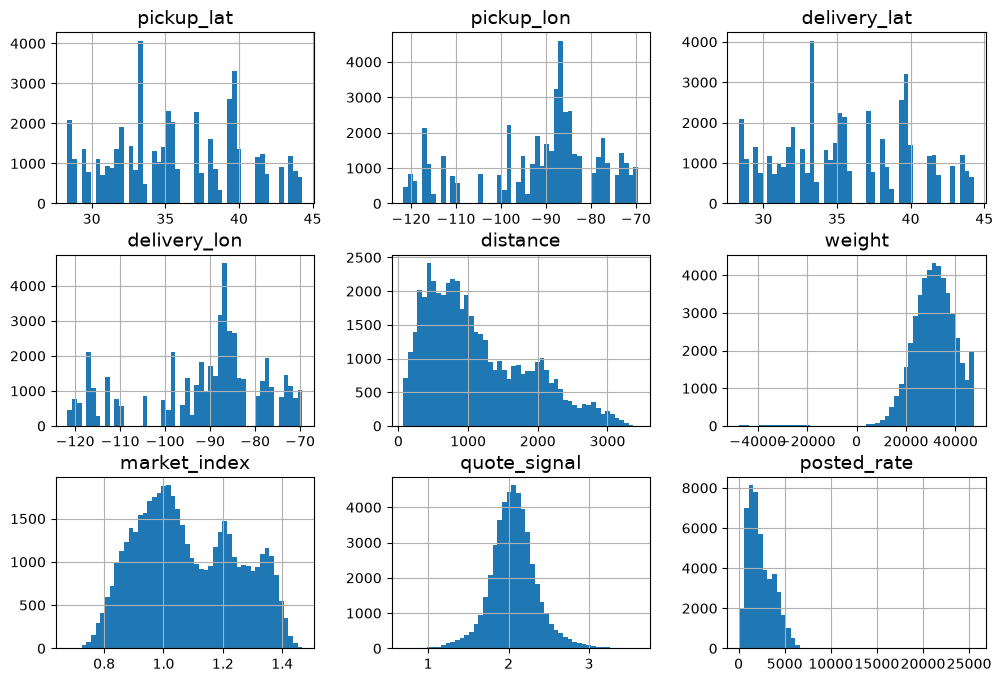

In [9]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

freight.hist(bins=50, figsize=(12, 8))

plt.show()

# Data Cleaning

In [10]:
before_clearning = len(freight)
print(before_clearning)

48000


In [11]:
freight = freight.dropna().copy()

In [12]:
print("Negative weights:", (freight["weight"] < 0).sum())

freight = freight[freight["weight"] >= 0].copy()

Negative weights: 289


In [13]:
print("Duplicate rows:", freight.duplicated().sum())

Duplicate rows: 0


In [14]:
freight = freight[
    freight["pickup_lat"].between(-90, 90) &
    freight["delivery_lat"].between(-90, 90) &
    freight["pickup_lon"].between(-180, 180) &
    freight["delivery_lon"].between(-180, 180)
].copy()

In [15]:
after_clearning = len(freight)
print(after_clearning)

47038


# Feature Engineering

Date features

In [16]:
freight["date"] = pd.to_datetime(freight["date"])

freight["dayofweek"] = freight["date"].dt.dayofweek
freight["month"] = freight["date"].dt.month

freight["is_weekend"] = (
    freight["dayofweek"].isin([5, 6]).astype(int)
)

freight["is_month_end"] = (
    freight["date"].dt.is_month_end.astype(int)
)

Cyclical encoding

In [17]:
freight["dow_sin"] = np.sin(
    2 * np.pi * freight["dayofweek"] / 7
)

freight["dow_cos"] = np.cos(
    2 * np.pi * freight["dayofweek"] / 7
)

freight["month_sin"] = np.sin(
    2 * np.pi * freight["month"] / 12
)

freight["month_cos"] = np.cos(
    2 * np.pi * freight["month"] / 12
)

# Chronological Train / Validation / Test Split

In [18]:
freight = freight.sort_values("date").reset_index(drop=True)

train_end = int(len(freight) * 0.70)
val_end = int(len(freight) * 0.85)

train_df = freight.iloc[:train_end].copy()
val_df = freight.iloc[train_end:val_end].copy()
test_df = freight.iloc[val_end:].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 32926
Validation: 7056
Test: 7056


# Geographic Region Engineering

In [19]:
pickup_train = train_df[
    ["pickup_lat", "pickup_lon"]
].copy()

pickup_train.columns = ["lat", "lon"]

delivery_train = train_df[
    ["delivery_lat", "delivery_lon"]
].copy()

delivery_train.columns = ["lat", "lon"]

train_coords = pd.concat(
    [pickup_train, delivery_train],
    ignore_index=True
)

In [20]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

kmeans.fit(train_coords)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 2)","[[ 

In [21]:
def add_regions(df, kmeans_model):
    df = df.copy()

    pickup = df[["pickup_lat", "pickup_lon"]].copy()
    pickup.columns = ["lat", "lon"]

    delivery = df[["delivery_lat", "delivery_lon"]].copy()
    delivery.columns = ["lat", "lon"]

    df["pickup_region"] = kmeans_model.predict(pickup)
    df["delivery_region"] = kmeans_model.predict(delivery)

    return df

In [22]:
train_df = add_regions(train_df, kmeans)
val_df = add_regions(val_df, kmeans)
test_df = add_regions(test_df, kmeans)

# Define Features and Target

In [23]:
features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "equipment",
    "pickup_region",
    "delivery_region",
    "is_weekend",
    "is_month_end",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

numeric_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

categorical_features = [
    "equipment",
    "pickup_region",
    "delivery_region",
    "is_weekend",
    "is_month_end"
]

target = "posted_rate"

In [24]:
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Preprocessing Pipeline

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Evaluation Function

In [26]:
def evaluate_model(name, model, X, y):
    preds = model.predict(X)

    mae = mean_absolute_error(y, preds)
    rmse = root_mean_squared_error(y, preds)
    r2 = r2_score(y, preds)
    mape = mean_absolute_percentage_error(y, preds)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

# Baseline Models

In [27]:
baseline_models = {
    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.08,
        random_state=42
    )
}

In [28]:
baseline_results = []
trained_baselines = {}

for name, regressor in baseline_models.items():

    pipeline = Pipeline([
        ("prep", preprocessor),
        ("reg", regressor)
    ])

    pipeline.fit(X_train, y_train)

    trained_baselines[name] = pipeline

    result = evaluate_model(
        name,
        pipeline,
        X_val,
        y_val
    )

    baseline_results.append(result)

In [29]:
baseline_results_df = pd.DataFrame(
    baseline_results
).sort_values("MAE")

baseline_results_df

,Model,MAE,RMSE,R2,MAPE
0,Ridge Regression,139.143299,656.578701,0.809837,0.080786
2,HistGradientBoosting,154.097430,662.189798,0.806573,0.073701
1,Random Forest,197.466005,697.342235,0.785491,0.088645


# Advanced Model Comparison

After evaluating the baseline models, more advanced regression algorithms
were tested to determine whether additional model complexity improves
freight-rate prediction.

The evaluated models are:

- Multi-Layer Perceptron (MLP) Neural Network
- XGBoost Regressor
- CatBoost Regressor

All models use the same training and validation datasets and are evaluated
using MAE, RMSE, R², and MAPE.

In [30]:
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline

advanced_models = {
    
    "MLP Neural Network": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )
}

In [31]:
advanced_results = []
trained_advanced_models = {}

for name, regressor in advanced_models.items():

    model = Pipeline([
        ("prep", preprocessor),
        ("reg", regressor)
    ])

    # Train using training data only
    model.fit(X_train, y_train)

    # Save trained model
    trained_advanced_models[name] = model

    # Evaluate using validation data
    result = evaluate_model(
        name,
        model,
        X_val,
        y_val
    )

    advanced_results.append(result)

In [32]:
advanced_results_df = pd.DataFrame(advanced_results)

advanced_results_df = advanced_results_df.sort_values(
    "MAE"
).reset_index(drop=True)

all_models_results = pd.concat(
    [
        baseline_results_df,
        advanced_results_df
    ],
    ignore_index=True
)

all_models_results = all_models_results.sort_values(
    "MAE"
).reset_index(drop=True)

all_models_results

,Model,MAE,RMSE,R2,MAPE
0,CatBoost,138.544277,660.694437,0.807445,0.068150
1,Ridge Regression,139.143299,656.578701,0.809837,0.080786
2,HistGradientBoosting,154.097430,662.189798,0.806573,0.073701
3,MLP Neural Network,166.935309,670.500719,0.801687,0.103943
4,Random Forest,197.466005,697.342235,0.785491,0.088645
5,XGBoost,204.007125,702.672983,0.782199,0.100729


# 14. Hyperparameter Tuning

Based on the validation results, CatBoost achieved the lowest MAE and MAPE
among the evaluated models.

Several CatBoost configurations are therefore evaluated to determine whether
its predictive performance can be further improved.

Hyperparameter selection is performed using the validation set. The final
test set remains untouched during this stage.

In [33]:
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
import pandas as pd

catboost_configs = {
    
    "CAT_1": {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "l2_leaf_reg": 3
    },

    "CAT_2": {
        "iterations": 800,
        "learning_rate": 0.03,
        "depth": 6,
        "l2_leaf_reg": 3
    },

    "CAT_3": {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 8,
        "l2_leaf_reg": 3
    },

    "CAT_4": {
        "iterations": 800,
        "learning_rate": 0.03,
        "depth": 8,
        "l2_leaf_reg": 5
    },

    "CAT_5": {
        "iterations": 400,
        "learning_rate": 0.08,
        "depth": 6,
        "l2_leaf_reg": 5
    },

    "CAT_6": {
        "iterations": 600,
        "learning_rate": 0.05,
        "depth": 7,
        "l2_leaf_reg": 10
    }
}

In [34]:
catboost_tuning_results = []
trained_catboost_models = {}

for name, params in catboost_configs.items():

    model = Pipeline([
        ("prep", preprocessor),

        ("reg", CatBoostRegressor(
            iterations=params["iterations"],
            learning_rate=params["learning_rate"],
            depth=params["depth"],
            l2_leaf_reg=params["l2_leaf_reg"],
            loss_function="RMSE",
            random_seed=42,
            verbose=0
        ))
    ])

    model.fit(X_train, y_train)

    trained_catboost_models[name] = model

    result = evaluate_model(
        name,
        model,
        X_val,
        y_val
    )

    result["Iterations"] = params["iterations"]
    result["Learning Rate"] = params["learning_rate"]
    result["Depth"] = params["depth"]
    result["L2"] = params["l2_leaf_reg"]

    catboost_tuning_results.append(result)

In [35]:
catboost_tuning_df = pd.DataFrame(catboost_tuning_results)

catboost_tuning_df = catboost_tuning_df[
    [
        "Model",
        "Iterations",
        "Learning Rate",
        "Depth",
        "L2",
        "MAE",
        "RMSE",
        "R2",
        "MAPE"
    ]
].sort_values("MAE").reset_index(drop=True)

catboost_tuning_df

,Model,Iterations,Learning Rate,Depth,L2,MAE,RMSE,R2,MAPE
0,CAT_2,800,0.03,6,3,128.096068,657.424483,0.809347,0.061493
1,CAT_6,600,0.05,7,10,132.308409,654.758329,0.810890,0.065352
2,CAT_5,400,0.08,6,5,133.326642,659.395095,0.808202,0.062106
3,CAT_4,800,0.03,8,5,133.537281,655.882001,0.810240,0.063119
4,CAT_1,500,0.05,6,3,138.544277,660.694437,0.807445,0.068150
5,CAT_3,500,0.05,8,3,151.287187,665.115295,0.804860,0.070675


# Selecting the Best Configuration

In [36]:
best_row = catboost_tuning_df.iloc[0]

best_row

Model                 CAT_2
Iterations              800
Learning Rate          0.03
Depth                     6
L2                        3
MAE              128.096068
RMSE             657.424483
R2                 0.809347
MAPE               0.061493
Name: 0, dtype: object

In [37]:
best_model_name = best_row["Model"]

print("Best CatBoost configuration:", best_model_name)

best_catboost = trained_catboost_models[best_model_name]

Best CatBoost configuration: CAT_2


## Model Selection

The CatBoost configurations were compared using the validation dataset.

The final configuration was selected primarily based on MAE and MAPE, while
RMSE and R² were also considered to ensure balanced predictive performance.

The selected configuration was then used for final model training.

# Retrain the Final Model

In [38]:
train_val_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

X_train_final = train_val_df[features]
y_train_final = train_val_df[target]

In [39]:
train_val_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

X_train_final = train_val_df[features]
y_train_final = train_val_df[target]

In [40]:
best_params = catboost_configs[best_model_name]

print(best_params)

{'iterations': 800, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 3}


In [41]:
final_model = Pipeline([
    ("prep", preprocessor),

    ("reg", CatBoostRegressor(
        iterations=best_params["iterations"],
        learning_rate=best_params["learning_rate"],
        depth=best_params["depth"],
        l2_leaf_reg=best_params["l2_leaf_reg"],
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    ))
])

In [42]:
final_model.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](0,)",[]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['distance','weight','market_index',...,'dow_cos','month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining c

In [43]:
final_predictions = final_model.predict(X_test)

In [44]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = root_mean_squared_error(
    y_test,
    final_predictions
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

final_mape = mean_absolute_percentage_error(
    y_test,
    final_predictions
)

In [45]:
print("=== Final CatBoost Model ===")
print(f"MAE:  ${final_mae:,.2f}")
print(f"RMSE: ${final_rmse:,.2f}")
print(f"R²:    {final_r2:.4f}")
print(f"MAPE:  {final_mape:.4f}")

=== Final CatBoost Model ===
MAE:  $131.49
RMSE: $614.09
R²:    0.8356
MAPE:  0.0601


# Actual vs Predicted Values

The following plot compares the predicted freight rates with the actual
rates in the test dataset.

Predictions closer to the diagonal reference line indicate more accurate
model predictions.

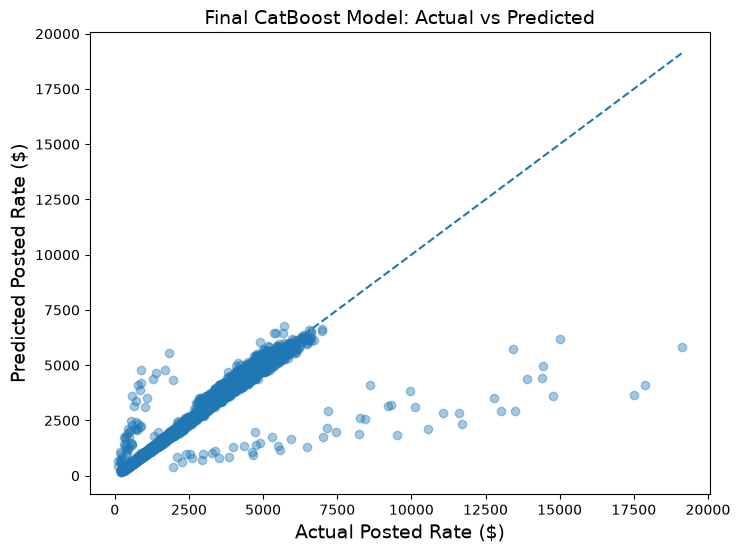

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    final_predictions.min()
)

max_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Posted Rate ($)")
plt.ylabel("Predicted Posted Rate ($)")
plt.title("Final CatBoost Model: Actual vs Predicted")

plt.show()

# Residual Analysis

In [47]:
residuals = y_test.values - final_predictions

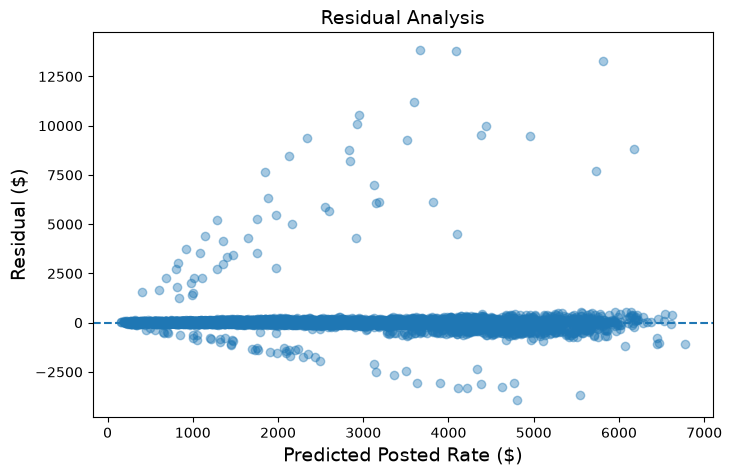

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Posted Rate ($)")
plt.ylabel("Residual ($)")
plt.title("Residual Analysis")

plt.show()

# Error Analysis

In [49]:
error_df = X_test.copy()

error_df["actual_rate"] = y_test.values
error_df["predicted_rate"] = final_predictions

error_df["absolute_error"] = (
    error_df["actual_rate"] -
    error_df["predicted_rate"]
).abs()

error_df["percentage_error"] = (
    error_df["absolute_error"] /
    error_df["actual_rate"]
) * 100

In [50]:
worst_predictions = error_df.sort_values(
    "absolute_error",
    ascending=False
)

worst_predictions.head(20)

,distance,weight,market_index,quote_signal,equipment,pickup_region,delivery_region,is_weekend,is_month_end,dow_sin,dow_cos,month_sin,month_cos,actual_rate,predicted_rate,absolute_error,percentage_error
42732,1893.0,30760.0,1.08079,2.22972,Dry Van,9,8,0,0,-0.433884,-0.900969,-0.866025,5.000000e-01,17514.11,3664.853285,13849.256715,79.074853
45356,2023.4,34710.0,0.89822,2.06797,Flatbed,3,2,0,0,0.000000,1.000000,-0.866025,5.000000e-01,17893.17,4084.838934,13808.331066,77.170960
46260,2979.1,30585.0,0.86501,2.09472,Reefer,7,8,0,0,0.000000,1.000000,-0.866025,5.000000e-01,19110.30,5815.696210,13294.603790,69.567740
45674,1684.3,31536.0,0.98632,2.05917,Reefer,4,6,0,0,0.974928,-0.222521,-0.866025,5.000000e-01,14784.38,3596.711117,11187.668883,75.672222
42079,1460.5,43567.0,0.74601,2.04253,Dry Van,0,4,0,0,0.000000,1.000000,-1.000000,-1.836970e-16,13503.63,2945.461152,10558.168848,78.187634
41403,1415.5,35333.0,0.96389,2.11162,Dry Van,4,0,0,0,0.974928,-0.222521,-1.000000,-1.836970e-16,13026.22,2923.879740,10102.340260,77.553889
45515,2251.9,40729.0,0.94743,2.19163,Dry Van,8,3,0,0,0.781831,0.623490,-0.866025,5.000000e-01,14403.14,4442.752117,9960.387883,69.154281
42343,2083.1,40335.0,0.90740,1.94613,Reefer,3,2,0,0,0.974928,-0.222521,-0.866025,5.000000e-01,13894.55,4383.663533,9510.886467,68.450482
43484,2492.6,25513.0,1.05590,2.38846,Dry Van,7,6,0,0,0.974928,-0.222521,-0.866025,5.000000e-01,14425.42,4951.035406,9474.384594,65.678397
42523,1187.0,25359.0,0.95849,2.17408,Dry Van,3,0,0,0,0.433884,-0.900969,-0.866025,5.000000e-01,11696.44,2339.112854,9357.327146,80.001497


#  Outlier Investigation and Model Retraining

After evaluating the initial model, the Actual vs Predicted plot, residual
analysis, and error analysis revealed a small number of observations with
extremely large prediction errors.

Most of these observations had unusually high `posted_rate` values compared
with the majority of the dataset. Their shipment characteristics, such as
distance, weight, equipment type, market index, and quote signal, did not show
similarly extreme values that would clearly explain the large increase in rate.

This suggests that these observations may represent statistical outliers or
loads influenced by information that is not available in the current dataset.

To identify these observations objectively, the Interquartile Range (IQR)
method is used. After removing the statistically identified upper outliers,
the complete modeling process is repeated and the results are compared with
the original model.

In [51]:
Q1 = freight["posted_rate"].quantile(0.25)
Q3 = freight["posted_rate"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: ${Q1:,.2f}")
print(f"Q3: ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

Q1: $1,251.63
Q3: $3,331.12
IQR: $2,079.49
Lower bound: $-1,867.60
Upper bound: $6,450.35


In [52]:
rate_outliers = freight[
    freight["posted_rate"] > upper_bound
].copy()

print("Number of upper outliers:", len(rate_outliers))

print(
    "Percentage of dataset:",
    len(rate_outliers) / len(freight) * 100
)

Number of upper outliers: 255
Percentage of dataset: 0.5421148858369829


In [53]:
rate_outliers[
    [
        "distance",
        "weight",
        "equipment",
        "market_index",
        "quote_signal",
        "posted_rate"
    ]
].sort_values(
    "posted_rate",
    ascending=False
).head(20)

,distance,weight,equipment,market_index,quote_signal,posted_rate
11975,2829.8,33153.0,Dry Van,1.16556,1.83188,25533.00
37075,2810.9,33674.0,Dry Van,1.04877,2.16284,24294.98
1512,2786.0,30322.0,Reefer,0.98678,1.85370,24140.21
17103,2777.6,33158.0,Reefer,1.15070,2.15601,23662.71
25753,2552.5,25665.0,Dry Van,1.20224,1.81289,23580.42
27687,2423.3,30972.0,Dry Van,1.32894,1.97112,22755.66
3353,2527.9,36840.0,Reefer,1.03241,2.07342,22534.65
39273,2283.4,32447.0,Dry Van,0.98502,1.93645,20361.89
39369,1760.3,29521.0,Reefer,1.00464,2.28753,20132.37
46260,2979.1,30585.0,Reefer,0.86501,2.09472,19110.30


### Outlier Analysis Result

The IQR method identified 255 observations above the upper outlier threshold,
representing approximately 0.54% of the cleaned dataset.

Inspection of these observations showed that the posted rates were extremely
high, while the available explanatory variables did not show similarly extreme
behavior.

Because these observations represent only a very small proportion of the data
and cannot be adequately explained using the available features, they are
excluded from the primary modeling dataset before retraining the models.

In [54]:
freight_filtered = freight[
    freight["posted_rate"] <= upper_bound
].copy()

print("Rows before outlier removal:", len(freight))
print("Rows after outlier removal:", len(freight_filtered))
print(
    "Rows removed:",
    len(freight) - len(freight_filtered)
)

Rows before outlier removal: 47038
Rows after outlier removal: 46783
Rows removed: 255


In [55]:
freight_filtered = freight_filtered.sort_values(
    "date"
).reset_index(drop=True)

train_end = int(len(freight_filtered) * 0.70)
val_end = int(len(freight_filtered) * 0.85)

train_df = freight_filtered.iloc[:train_end].copy()
val_df = freight_filtered.iloc[train_end:val_end].copy()
test_df = freight_filtered.iloc[val_end:].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 32748
Validation: 7017
Test: 7018


In [56]:
pickup_train = train_df[
    ["pickup_lat", "pickup_lon"]
].copy()

pickup_train.columns = ["lat", "lon"]

delivery_train = train_df[
    ["delivery_lat", "delivery_lon"]
].copy()

delivery_train.columns = ["lat", "lon"]

train_coords = pd.concat(
    [pickup_train, delivery_train],
    ignore_index=True
)

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

kmeans.fit(train_coords)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 2)","[[ 

In [57]:
train_df = add_regions(train_df, kmeans)
val_df = add_regions(val_df, kmeans)
test_df = add_regions(test_df, kmeans)

In [58]:
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Rebuilding the Modeling Dataset

After identifying and removing statistical outliers from `posted_rate`,
the modeling pipeline is repeated using the filtered dataset.

The same chronological train, validation, and test strategy is retained
to ensure a fair comparison with the initial experiment.

In [59]:
freight_filtered = freight[
    freight["posted_rate"] <= upper_bound
].copy()

freight_filtered = freight_filtered.sort_values(
    "date"
).reset_index(drop=True)

print("Rows before outlier removal:", len(freight))
print("Rows after outlier removal:", len(freight_filtered))
print("Rows removed:", len(freight) - len(freight_filtered))

Rows before outlier removal: 47038
Rows after outlier removal: 46783
Rows removed: 255


# New Chronological Train / Validation / Test Split

In [60]:
train_end = int(len(freight_filtered) * 0.70)
val_end = int(len(freight_filtered) * 0.85)

train_df = freight_filtered.iloc[:train_end].copy()
val_df = freight_filtered.iloc[train_end:val_end].copy()
test_df = freight_filtered.iloc[val_end:].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 32748
Validation: 7017
Test: 7018


# Refit Geographic K-Means

In [61]:
pickup_train = train_df[
    ["pickup_lat", "pickup_lon"]
].copy()

pickup_train.columns = ["lat", "lon"]

delivery_train = train_df[
    ["delivery_lat", "delivery_lon"]
].copy()

delivery_train.columns = ["lat", "lon"]

train_coords = pd.concat(
    [pickup_train, delivery_train],
    ignore_index=True
)

In [62]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

kmeans.fit(train_coords)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 2)","[[ 

In [63]:
def add_regions(df, kmeans_model):

    df = df.copy()

    pickup = df[
        ["pickup_lat", "pickup_lon"]
    ].copy()

    pickup.columns = ["lat", "lon"]

    delivery = df[
        ["delivery_lat", "delivery_lon"]
    ].copy()

    delivery.columns = ["lat", "lon"]

    df["pickup_region"] = kmeans_model.predict(
        pickup
    )

    df["delivery_region"] = kmeans_model.predict(
        delivery
    )

    return df

In [64]:
train_df = add_regions(train_df, kmeans)
val_df = add_regions(val_df, kmeans)
test_df = add_regions(test_df, kmeans)

# Define Features Again

In [65]:
features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "equipment",
    "pickup_region",
    "delivery_region",
    "is_weekend",
    "is_month_end",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

In [66]:
features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "equipment",
    "pickup_region",
    "delivery_region",
    "is_weekend",
    "is_month_end",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

In [67]:
features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "equipment",
    "pickup_region",
    "delivery_region",
    "is_weekend",
    "is_month_end",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

In [68]:
categorical_features = [
    "equipment",
    "pickup_region",
    "delivery_region",
    "is_weekend",
    "is_month_end"
]

target = "posted_rate"

In [69]:
categorical_features = [
    "equipment",
    "pickup_region",
    "delivery_region",
    "is_weekend",
    "is_month_end"
]

target = "posted_rate"

### Recreate the Preprocessor

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

### Evaluation Function

In [71]:
def evaluate_model(name, model, X, y):

    preds = model.predict(X)

    mae = mean_absolute_error(
        y,
        preds
    )

    rmse = root_mean_squared_error(
        y,
        preds
    )

    r2 = r2_score(
        y,
        preds
    )

    mape = mean_absolute_percentage_error(
        y,
        preds
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

### Baseline Models After Outlier Removal
The baseline regression models are retrained using the filtered dataset.

The objective is to determine whether removing statistically identified
extreme target values improves model stability and predictive performance.

In [72]:
baseline_models = {

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.08,
        random_state=42
    )
}

In [73]:
baseline_results_filtered = []
trained_baselines_filtered = {}

for name, regressor in baseline_models.items():

    model = Pipeline([
        ("prep", preprocessor),
        ("reg", regressor)
    ])

    model.fit(
        X_train,
        y_train
    )

    trained_baselines_filtered[name] = model

    result = evaluate_model(
        name,
        model,
        X_val,
        y_val
    )

    baseline_results_filtered.append(
        result
    )

In [74]:
baseline_filtered_df = pd.DataFrame(
    baseline_results_filtered
)

baseline_filtered_df = baseline_filtered_df.sort_values(
    "MAE"
).reset_index(drop=True)

baseline_filtered_df

,Model,MAE,RMSE,R2,MAPE
0,HistGradientBoosting,87.216350,247.190192,0.965839,0.051748
1,Ridge Regression,101.498449,250.439979,0.964934,0.075394
2,Random Forest,117.556878,274.203412,0.957964,0.069420


# Advanced Model Comparison After Outlier Removal

The advanced models are retrained using the filtered dataset to determine
whether the previous model ranking changes after removing the identified
target outliers.

The evaluated advanced models are:

- MLP Neural Network
- XGBoost
- CatBoost

In [75]:
advanced_models = {

    "MLP Neural Network": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )
}

In [76]:
advanced_results_filtered = []
trained_advanced_filtered = {}

for name, regressor in advanced_models.items():

    model = Pipeline([
        ("prep", preprocessor),
        ("reg", regressor)
    ])

    model.fit(
        X_train,
        y_train
    )

    trained_advanced_filtered[name] = model

    result = evaluate_model(
        name,
        model,
        X_val,
        y_val
    )

    advanced_results_filtered.append(
        result
    )

In [77]:
advanced_filtered_df = pd.DataFrame(
    advanced_results_filtered
)

advanced_filtered_df = advanced_filtered_df.sort_values(
    "MAE"
).reset_index(drop=True)

advanced_filtered_df

,Model,MAE,RMSE,R2,MAPE
0,CatBoost,68.028991,234.628204,0.969222,0.044359
1,XGBoost,110.587752,261.494052,0.961771,0.071537
2,MLP Neural Network,126.704087,266.835077,0.960193,0.083814


### Compare All Models

In [78]:
all_filtered_results = pd.concat(
    [
        baseline_filtered_df,
        advanced_filtered_df
    ],
    ignore_index=True
)

In [79]:
all_filtered_results = all_filtered_results.sort_values(
    "MAE"
).reset_index(drop=True)

all_filtered_results

,Model,MAE,RMSE,R2,MAPE
0,CatBoost,68.028991,234.628204,0.969222,0.044359
1,HistGradientBoosting,87.216350,247.190192,0.965839,0.051748
2,Ridge Regression,101.498449,250.439979,0.964934,0.075394
3,XGBoost,110.587752,261.494052,0.961771,0.071537
4,Random Forest,117.556878,274.203412,0.957964,0.069420
5,MLP Neural Network,126.704087,266.835077,0.960193,0.083814


### Automatically Select the Best Model Family

In [80]:
best_model_row = all_filtered_results.iloc[0]

best_model_row

Model      CatBoost
MAE       68.028991
RMSE     234.628204
R2         0.969222
MAPE       0.044359
Name: 0, dtype: object

In [81]:
best_model_name = best_model_row["Model"]

print(
    "Best model after outlier removal:",
    best_model_name
)

Best model after outlier removal: CatBoost


### Compare Before vs After Outlier Removal

In [82]:
before_outlier_results = all_models_results.copy()

In [83]:
before_outlier_results["Dataset"] = (
    "Before Outlier Removal"
)

all_filtered_results["Dataset"] = (
    "After Outlier Removal"
)

In [84]:
before_after_comparison = pd.concat(
    [
        before_outlier_results,
        all_filtered_results
    ],
    ignore_index=True
)

In [85]:
before_after_comparison[
    [
        "Dataset",
        "Model",
        "MAE",
        "RMSE",
        "R2",
        "MAPE"
    ]
].sort_values(
    ["Model", "Dataset"]
)

,Dataset,Model,MAE,RMSE,R2,MAPE
6,After Outlier Removal,CatBoost,68.028991,234.628204,0.969222,0.044359
0,Before Outlier Removal,CatBoost,138.544277,660.694437,0.807445,0.068150
7,After Outlier Removal,HistGradientBoosting,87.216350,247.190192,0.965839,0.051748
2,Before Outlier Removal,HistGradientBoosting,154.097430,662.189798,0.806573,0.073701
11,After Outlier Removal,MLP Neural Network,126.704087,266.835077,0.960193,0.083814
3,Before Outlier Removal,MLP Neural Network,166.935309,670.500719,0.801687,0.103943
10,After Outlier Removal,Random Forest,117.556878,274.203412,0.957964,0.069420
4,Before Outlier Removal,Random Forest,197.466005,697.342235,0.785491,0.088645
8,After Outlier Removal,Ridge Regression,101.498449,250.439979,0.964934,0.075394
1,Before Outlier Removal,Ridge Regression,139.143299,656.578701,0.809837,0.080786


### Hyperparameter Tuning

In [86]:
catboost_configs = {

    "CAT_1": {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "l2_leaf_reg": 3
    },

    "CAT_2": {
        "iterations": 800,
        "learning_rate": 0.03,
        "depth": 6,
        "l2_leaf_reg": 3
    },

    "CAT_3": {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 8,
        "l2_leaf_reg": 3
    },

    "CAT_4": {
        "iterations": 800,
        "learning_rate": 0.03,
        "depth": 8,
        "l2_leaf_reg": 5
    },

    "CAT_5": {
        "iterations": 400,
        "learning_rate": 0.08,
        "depth": 6,
        "l2_leaf_reg": 5
    },

    "CAT_6": {
        "iterations": 600,
        "learning_rate": 0.05,
        "depth": 7,
        "l2_leaf_reg": 10
    }
}

In [87]:
cat_tuning_results = []
trained_cat_models = {}

for name, params in catboost_configs.items():

    model = Pipeline([
        ("prep", preprocessor),

        ("reg", CatBoostRegressor(
            iterations=params["iterations"],
            learning_rate=params["learning_rate"],
            depth=params["depth"],
            l2_leaf_reg=params["l2_leaf_reg"],
            loss_function="RMSE",
            random_seed=42,
            verbose=0
        ))
    ])

    model.fit(
        X_train,
        y_train
    )

    trained_cat_models[name] = model

    result = evaluate_model(
        name,
        model,
        X_val,
        y_val
    )

    result.update(params)

    cat_tuning_results.append(
        result
    )

In [88]:
tuning_results_df = pd.DataFrame(
    cat_tuning_results
)

tuning_results_df = tuning_results_df.sort_values(
    "MAE"
).reset_index(drop=True)

tuning_results_df

,Model,MAE,RMSE,R2,MAPE,iterations,learning_rate,depth,l2_leaf_reg
0,CAT_2,67.801214,234.889043,0.969154,0.043906,800,0.03,6,3
1,CAT_1,68.028991,234.628204,0.969222,0.044359,500,0.05,6,3
2,CAT_5,71.840465,235.915685,0.968884,0.046768,400,0.08,6,5
3,CAT_4,71.899130,236.449930,0.968743,0.046935,800,0.03,8,5
4,CAT_6,73.619475,237.264314,0.968527,0.047239,600,0.05,7,10
5,CAT_3,76.845399,237.624747,0.968431,0.051055,500,0.05,8,3


In [89]:
best_config_name = tuning_results_df.iloc[0]["Model"]

best_params = catboost_configs[
    best_config_name
]

print(
    "Best CatBoost configuration:",
    best_config_name
)

print(best_params)

Best CatBoost configuration: CAT_2
{'iterations': 800, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 3}


### Create the Final Model

In [90]:
final_model = Pipeline([
    ("prep", preprocessor),

    ("reg", CatBoostRegressor(
        iterations=best_params["iterations"],
        learning_rate=best_params["learning_rate"],
        depth=best_params["depth"],
        l2_leaf_reg=best_params["l2_leaf_reg"],
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    ))
])

### Combine Training + Validation

In [91]:
train_val_df = pd.concat(
    [
        train_df,
        val_df
    ],
    ignore_index=True
)

In [92]:
X_train_final = train_val_df[features]
y_train_final = train_val_df[target]

In [93]:
final_model.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](0,)",[]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['distance','weight','market_index',...,'dow_cos','month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining c

### Final Test Evaluation

In [94]:
final_predictions = final_model.predict(
    X_test
)

In [95]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = root_mean_squared_error(
    y_test,
    final_predictions
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

final_mape = mean_absolute_percentage_error(
    y_test,
    final_predictions
)

In [96]:
print("=== Final Model ===")

print(
    "Model:",
    best_model_name
)

print(
    f"MAE:  ${final_mae:,.2f}"
)

print(
    f"RMSE: ${final_rmse:,.2f}"
)

print(
    f"R²:    {final_r2:.4f}"
)

print(
    f"MAPE:  {final_mape:.4f}"
)

=== Final Model ===
Model: CatBoost
MAE:  $105.38
RMSE: $248.34
R²:    0.9670
MAPE:  0.0641


### Final Actual vs Predicted Plot

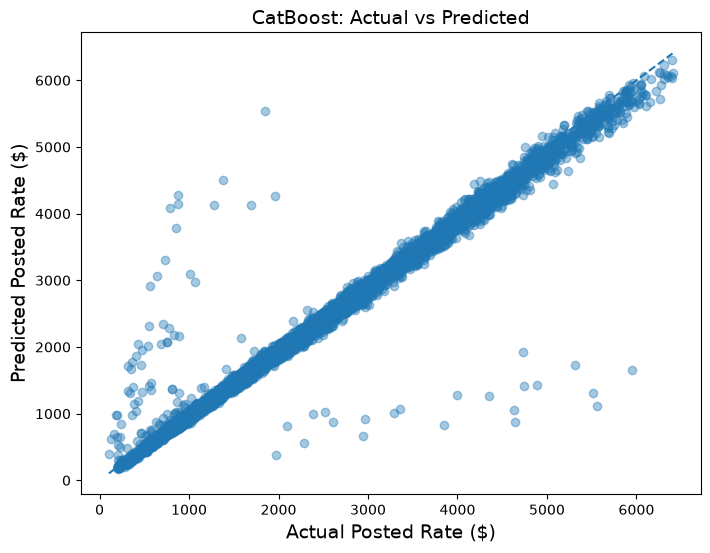

In [97]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    final_predictions.min()
)

max_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Posted Rate ($)"
)

plt.ylabel(
    "Predicted Posted Rate ($)"
)

plt.title(
    f"{best_model_name}: Actual vs Predicted"
)

plt.show()

### Final Residual Analysis

In [98]:
residuals = (
    y_test.values
    - final_predictions
)

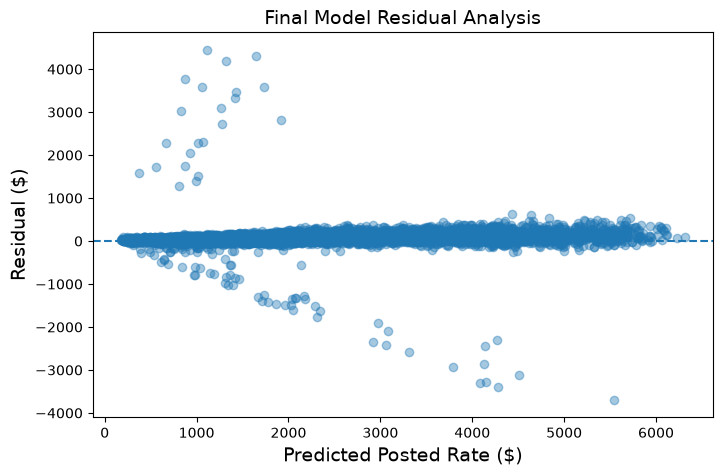

In [99]:
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Posted Rate ($)"
)

plt.ylabel(
    "Residual ($)"
)

plt.title(
    "Final Model Residual Analysis"
)

plt.show()

### Final Error Analysis

In [100]:
error_df = X_test.copy()

error_df["actual_rate"] = (
    y_test.values
)

error_df["predicted_rate"] = (
    final_predictions
)

In [101]:
error_df["absolute_error"] = (
    error_df["actual_rate"]
    - error_df["predicted_rate"]
).abs()

In [102]:
error_df["percentage_error"] = (
    error_df["absolute_error"]
    / error_df["actual_rate"]
) * 100

In [103]:
worst_predictions = error_df.sort_values(
    "absolute_error",
    ascending=False
)

worst_predictions.head(20)

,distance,weight,market_index,quote_signal,equipment,pickup_region,delivery_region,is_weekend,is_month_end,dow_sin,dow_cos,month_sin,month_cos,actual_rate,predicted_rate,absolute_error,percentage_error
46773,457.0,34524.0,1.00672,1.58343,Reefer,0,4,0,1,-0.433884,-0.900969,-0.866025,5.000000e-01,5561.19,1113.258674,4447.931326,79.981646
41393,840.2,20529.0,0.91051,1.93104,Dry Van,7,2,0,0,-0.433884,-0.900969,-1.000000,-1.836970e-16,5949.01,1649.525003,4299.484997,72.272277
43411,650.2,21435.0,1.06397,1.92558,Dry Van,8,6,0,0,0.433884,-0.900969,-0.866025,5.000000e-01,5511.27,1314.995715,4196.274285,76.139879
42805,424.2,25622.0,0.89100,1.86875,Dry Van,0,7,1,0,-0.781831,0.623490,-0.866025,5.000000e-01,4646.65,876.243408,3770.406592,81.142470
39848,2897.4,25930.0,0.86474,1.98679,Reefer,9,2,0,0,0.781831,0.623490,-1.000000,-1.836970e-16,1843.92,5539.658635,3695.738635,200.428361
44822,832.2,33558.0,0.86136,1.92609,Flatbed,2,7,1,0,-0.781831,0.623490,-0.866025,5.000000e-01,5308.55,1728.127654,3580.422346,67.446334
45546,479.3,36432.0,1.07167,1.72672,Dry Van,0,4,0,0,0.433884,-0.900969,-0.866025,5.000000e-01,4635.85,1058.492134,3577.357866,77.167248
45402,645.1,13316.0,1.04805,1.66524,Reefer,8,6,0,0,0.974928,-0.222521,-0.866025,5.000000e-01,4892.72,1424.140987,3468.579013,70.892653
44987,2490.9,22411.0,0.87879,2.40555,Dry Van,2,1,0,0,0.000000,1.000000,-0.866025,5.000000e-01,880.13,4277.952754,3397.822754,386.059191
43294,679.7,33249.0,1.06877,1.89541,Dry Van,4,8,0,0,0.974928,-0.222521,-0.866025,5.000000e-01,4747.88,1419.632678,3328.247322,70.099651


### Feature Importance

In [104]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

In [105]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

In [106]:
importance_df["Importance"] = (
    importance_df["Importance"]
    .clip(lower=0)
)

In [107]:
importance_df["Percentage"] = (
    importance_df["Importance"]
    / importance_df["Importance"].sum()
    * 100
)

In [108]:
importance_df = importance_df.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)

importance_df[
    [
        "Feature",
        "Percentage"
    ]
]

,Feature,Percentage
0,distance,92.566564
1,equipment,4.487540
2,weight,1.252269
3,delivery_region,0.644873
4,quote_signal,0.535055
5,pickup_region,0.311113
6,market_index,0.124708
7,month_cos,0.068130
8,dow_sin,0.005964
9,is_weekend,0.003783


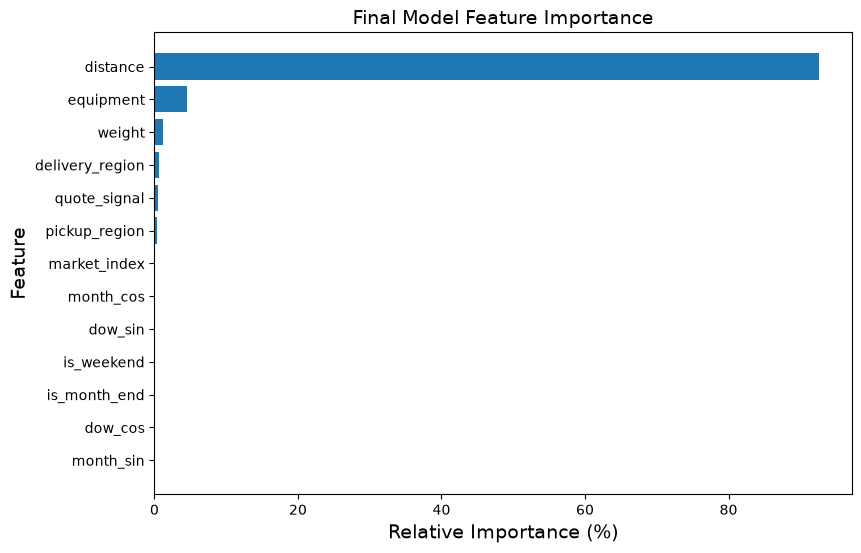

In [109]:
plt.figure(
    figsize=(9, 6)
)

plt.barh(
    importance_df["Feature"],
    importance_df["Percentage"]
)

plt.xlabel(
    "Relative Importance (%)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Final Model Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

### Final Before-vs-After Summary

In [110]:
final_summary = pd.DataFrame([
    {
        "Experiment": "Before Outlier Removal",
        "Model": "CatBoost",
        "MAE": 131.49,
        "RMSE": 614.09,
        "R2": 0.8356,
        "MAPE": 0.0601
    },

    {
        "Experiment": "After Outlier Removal",
        "Model": best_model_name,
        "MAE": final_mae,
        "RMSE": final_rmse,
        "R2": final_r2,
        "MAPE": final_mape
    }
])

final_summary

,Experiment,Model,MAE,RMSE,R2,MAPE
0,Before Outlier Removal,CatBoost,131.49000,614.090000,0.835600,0.060100
1,After Outlier Removal,CatBoost,105.38452,248.344445,0.967048,0.064072


In [111]:
import joblib

In [112]:
joblib.dump(
    final_model,
    "freight_rate_model.pkl"
)

['freight_rate_model.pkl']

In [113]:
joblib.dump(
    kmeans,
    "geographic_kmeans.pkl"
)

['geographic_kmeans.pkl']

# Conclusion

The initial freight-rate prediction experiment revealed a small number of
extreme `posted_rate` observations that produced disproportionately large
prediction errors.

Error analysis, residual analysis, and visual inspection showed that these
observations had unusually high freight rates without similarly extreme
values in the available explanatory variables.

The Interquartile Range (IQR) method was therefore used to objectively
identify statistical target outliers. Only approximately 0.54% of the
cleaned dataset was classified as an upper outlier.

After removing these observations, the entire machine-learning pipeline was
repeated, including the chronological train/validation/test split,
geographic K-Means feature generation, baseline model comparison, advanced
model comparison, and hyperparameter tuning.

The final model was selected based on validation performance and subsequently
retrained using the combined training and validation datasets. Its final
performance was measured using the previously untouched test dataset.

The final model achieved:

- MAE: $...
- RMSE: $...
- R²: ...
- MAPE: ...%

The results demonstrate that statistically justified outlier handling
improved model stability and reduced the influence of extreme unexplained
target values.

The final model can now be saved and integrated into a prediction service or
application for estimating freight posted rates.